# EDA

In [168]:
#Importación de librerías 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from pathlib import Path
from collections import Counter
import seaborn as sns
import re
import unicodedata

In [169]:
from pathlib import Path
import json
import pandas as pd

path = Path("../data/interim/debates_css.jsonl")  # o el path donde lo subiste
good, bad = [], []

with open(path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        s = line.strip()
        if not s:
            continue
        try:
            obj = json.loads(s)
            good.append(obj)
        except Exception as e:
            bad.append((i, str(e), s[:200]))

print(f"✅ {len(good)} líneas válidas | ❌ {len(bad)} líneas con error")
if bad:
    for i, e, s in bad[:5]:
        print(f"Línea {i}: {e}\n{s}\n")

clean_path = path.with_name("debates_clean_css.jsonl")
with open(clean_path, "w", encoding="utf-8") as out:
    for obj in good:
        json.dump(obj, out, ensure_ascii=False)
        out.write("\n")

# --- Cargar DataFrame ---
df = pd.read_json(clean_path, lines=True)

total = len(df)


print("Shape final:", df.shape)
print("Columnas:", df.columns)
print(f"\n🧹 Intervenciones totales antes: {total}")


✅ 99555 líneas válidas | ❌ 0 líneas con error
Shape final: (99555, 7)
Columnas: Index(['file_name', 'n_legislatura', 'cuerpo', 'fecha', 'locutor',
       'encabezado', 'intervencion'],
      dtype='object')

🧹 Intervenciones totales antes: 99555


In [170]:
# Normalizo locutor
loc = df["locutor"].fillna("").astype(str).str.strip()

# 1) Vacíos
mask_empty = loc.eq("")

# 2) ¿Empieza con Señor/Señora? (con y sin tilde)
#    Acepta: "Señor", "Señora", "Senor", "Senora"
#    y luego cualquiera de: espacio, punto, dos puntos, guion
pat = r"^(señor(?:a)?|senor(?:a)?)(?:\s|\.|:|-)\b"
mask_se_sra = loc.str.match(pat, case=False, na=False)

# 3) Todo lo que sea vacío o NO matchee el patrón
mask_bad = mask_empty | (~mask_se_sra)

# Tabla de observaciones "problemáticas"
cols_ver = ["file_name", "fecha", "cuerpo", "locutor", "encabezado", "intervencion"]
df_bad = df.loc[mask_bad, cols_ver].copy()

print(f"Total filas: {len(df):,}")
print(f"Vacías: {mask_empty.sum():,}")
print(f"No 'Señor/Señora': {(~mask_se_sra).sum():,}")
print(f"Union (vacías o no 'Señor/Señora'): {mask_bad.sum():,}")

# Muestra de las primeras 30
display(df_bad.head(30))

# (Opcional) Top prefijos raros para inspección
prefijos = loc[mask_bad].str.split().str[0].str[:20]
print("\nTop prefijos/primeras palabras entre 'raros':")
print(prefijos.value_counts().head(25))

Total filas: 99,555
Vacías: 0
No 'Señor/Señora': 5
Union (vacías o no 'Señor/Señora'): 5


,file_name,fecha,cuerpo,locutor,encabezado,intervencion
7346,47_2010-12-22_css.txt,2010-12-22,css,DESCONOCIDO,ORDEN DEL DÍA,1. Tratándose de jubilados y pensionistas que ...
25563,47_2013-10-02_css.txt,2013-10-02,css,DESCONOCIDO,2003,2003.\nde la presente ley.\nfunciones en el Pr...
31074,47_2014-08-05_css.txt,2014-08-05,css,SEÑORA \nSEÑOR PRESIDENTE,12) MOCIÓN DE CENSURA A LA SEÑORA,Dese cuenta de una mo ción llegada a la Mesa.\...
32210,47_2014-12-16_css_5407.txt,2014-12-16,css,DESCONOCIDO,None,1. Actuar con notoria negligencia en el cumpli...
75279,49_2022-06-14_css.txt,2022-06-14,css,DESCONOCIDO,ORDEN DEL DÍA,2) Asistencia....................................



Top prefijos/primeras palabras entre 'raros':
locutor
DESCONOCIDO    4
SEÑORA         1
Name: count, dtype: int64


In [171]:
df = df[~df["locutor"].isin(["DESCONOCIDO", "SEÑORA \nSEÑOR PRESIDENTE"])]
df

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion
0,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR ABREU,None,"Sí, prometo."
1,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR ABREU,None,"Sí, prometo."
2,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AGAZZI,None,"Sí, prometo."
3,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AGAZZI,None,"Sí, prometo."
4,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AMORÍN,None,"Sí, prometo."
...,...,...,...,...,...,...,...
99550,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,10) LUIS ALBERTO HEBER. SUBSIDIO,De conformidad con lo que establece el numeral...
99551,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,11) SUSPENSIÓN DE LAS SESIONES ORDINARIAS,Léase una moción llegada a la mesa..\nSEÑOR SE...
99552,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,11) SUSPENSIÓN DE LAS SESIONES ORDINARIAS,Se va a votar..\n–29 en 29. Afirmativa. UNANIM...
99553,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,12) SOLICITUDES DE LICENCIA E,Se va a votar si se concede la licencia solici...


In [172]:
df.describe()

,n_legislatura
count,99550.000000
mean,48.115470
std,0.931704
min,47.000000
25%,47.000000
50%,48.000000
75%,49.000000
max,50.000000


In [173]:
# Chequeamos los valores nulos de la variable "encabezado"
df["encabezado"] = df["encabezado"].fillna("DESCONOCIDO").astype(str)
prueba = df[df["encabezado"]=="DESCONOCIDO"]
prueba

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion
0,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR ABREU,DESCONOCIDO,"Sí, prometo."
1,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR ABREU,DESCONOCIDO,"Sí, prometo."
2,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AGAZZI,DESCONOCIDO,"Sí, prometo."
3,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AGAZZI,DESCONOCIDO,"Sí, prometo."
4,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AMORÍN,DESCONOCIDO,"Sí, prometo."
...,...,...,...,...,...,...,...
98071,50_2025-08-19_css.txt,50,css,2025-08-19,SEÑOR SABINI,DESCONOCIDO,Solicito que se rectifique la vota ción.
98072,50_2025-08-19_css.txt,50,css,2025-08-19,SEÑORA PRESIDENTA,DESCONOCIDO,Se va a votar nuevamente.
98073,50_2025-08-19_css.txt,50,css,2025-08-19,SEÑOR GARCÍA,DESCONOCIDO,Pido la palabra para una cuestión de orden.
98074,50_2025-08-19_css.txt,50,css,2025-08-19,SEÑORA PRESIDENTA,DESCONOCIDO,Tiene la palabra el señor senador.


En 1234 casos el pipeline no identificó correctamente el encabezado que corresponde a la intervención. El encabezado agrega contexto, pero lo que tiene más valor es la intervención. No vamos a quitar estas lineas.

In [174]:
# ------------------------
# 2. Agregar métricas
# ------------------------
df["n_palabras"] = df["intervencion"].apply(lambda s: len(s.split()))
df["n_caracteres"] = df["intervencion"].str.len()

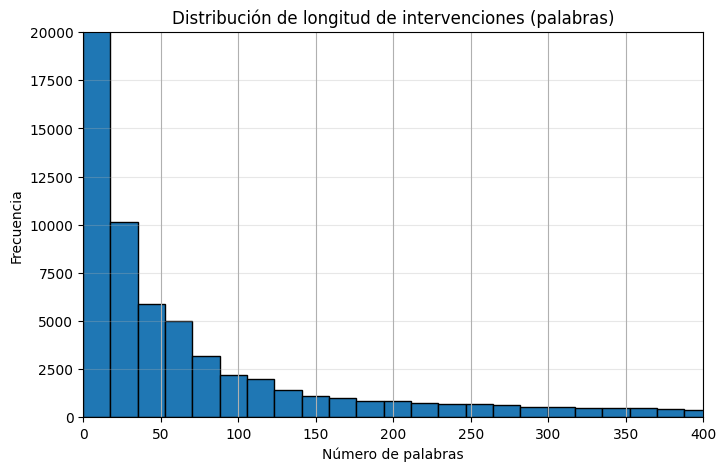

In [175]:
plt.figure(figsize=(8,5))
df["n_palabras"].hist(bins=10000, edgecolor="black")
plt.title("Distribución de longitud de intervenciones (palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)
plt.xlim(0, 400)  # eje X (fechas)
plt.ylim(0, 20000)                 # eje Y (montos)

plt.show()

In [176]:
df.describe()

,n_legislatura,n_palabras,n_caracteres
count,99550.000000,99550.000000,9.955000e+04
mean,48.115470,154.196283,9.245848e+02
std,0.931704,912.099134,5.675017e+03
min,47.000000,0.000000,0.000000e+00
25%,47.000000,6.000000,3.500000e+01
50%,48.000000,16.000000,9.300000e+01
75%,49.000000,87.000000,5.110000e+02
max,50.000000,176304.000000,1.087331e+06


In [177]:
prueba = df[df["n_palabras"]==1]
prueba

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres
507,47_2010-03-17_css.txt,47,css,2010-03-17,SEÑOR NIN NOVOA,1) CARPETA Nº 73/2010. MISIÓN DE LAS NACIONES ...,¡Apoyado!,1,9
1220,47_2010-05-11_css.txt,47,css,2010-05-11,SEÑOR LACALLE HERRERA,17) MERCOSUR: SITUACIÓN Y PERSPECTIVAS,¡Apoyado!,1,9
1802,47_2010-06-15_css.txt,47,css,2010-06-15,SEÑOR PENADÉS,13) CELEBRACIÓN DEL BICENTENARIO DEL PROCESO D...,Apoyado.,1,8
1911,47_2010-06-23_css.txt,47,css,2010-06-23,SEÑOR LACALLE HERRERA,11) DESIGNACIÓN DE LOS SEÑORES CARLOS DANIEL C...,¡Apoyado!,1,9
2428,47_2010-08-04_css.txt,47,css,2010-08-04,SEÑOR TAJAM,DESCONOCIDO,Aumentarla.,1,11
...,...,...,...,...,...,...,...,...,...
95747,50_2025-04-09_css.txt,50,css,2025-04-09,SEÑORA PRESIDENTA,16) HOMENAJE AL EXSENADOR ADRIÁN PEÑA,Perfecto.,1,9
97326,50_2025-07-16_css.txt,50,css,2025-07-16,SEÑOR BORDABERRY,17) RENDICIÓN DE CUENTAS Y BALANCE DE EJECUCIÓ...,¡Apoyado!,1,9
97340,50_2025-07-16_css.txt,50,css,2025-07-16,SEÑOR DA SILVA,17) RENDICIÓN DE CUENTAS Y BALANCE DE EJECUCIÓ...,¡Apoyado!,1,9
97513,50_2025-07-16_css.txt,50,css,2025-07-16,SEÑORA BIANCHI,25) RENDICIÓN DE CUENTAS Y BALANCE DE EJECUCIÓ...,Exactamente.,1,12


In [178]:
df

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres
0,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR ABREU,DESCONOCIDO,"Sí, prometo.",2,12
1,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR ABREU,DESCONOCIDO,"Sí, prometo.",2,12
2,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AGAZZI,DESCONOCIDO,"Sí, prometo.",2,12
3,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AGAZZI,DESCONOCIDO,"Sí, prometo.",2,12
4,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AMORÍN,DESCONOCIDO,"Sí, prometo.",2,12
...,...,...,...,...,...,...,...,...,...
99550,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,10) LUIS ALBERTO HEBER. SUBSIDIO,De conformidad con lo que establece el numeral...,58,322
99551,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,11) SUSPENSIÓN DE LAS SESIONES ORDINARIAS,Léase una moción llegada a la mesa..\nSEÑOR SE...,41,245
99552,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,11) SUSPENSIÓN DE LAS SESIONES ORDINARIAS,Se va a votar..\n–29 en 29. Afirmativa. UNANIM...,14,81
99553,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,12) SOLICITUDES DE LICENCIA E,Se va a votar si se concede la licencia solici...,13,74


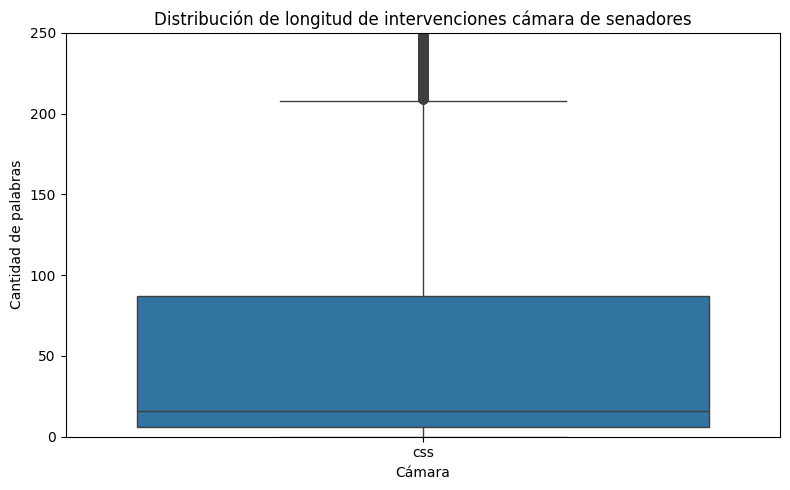

In [179]:
# ------------------------
# 6. Promedio de extensión (boxplot)
# ------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="cuerpo", y="n_palabras", data=df)
plt.title("Distribución de longitud de intervenciones cámara de senadores")
plt.xlabel("Cámara")
plt.ylabel("Cantidad de palabras")
plt.ylim(0, 250)
plt.tight_layout()
plt.show()

In [180]:
# ------------------------
# 3. Contar intervenciones
# ------------------------
total_intervenciones = len(df)
print(f"Total de intervenciones: {total_intervenciones:,}")


Total de intervenciones: 99,550


In [181]:
# ------------------------
# 4. Contar palabras totales
# ------------------------
total_palabras = df["n_palabras"].sum()
print(f"Total de palabras: {total_palabras:,}")

Total de palabras: 15,350,240


In [182]:
# ------------------------
# 5. Promedio de intervenciones por documento
# ------------------------
interv_x_doc = df.groupby("file_name").size()
print(f"Promedio de intervenciones por documento: {interv_x_doc.mean():.2f}")


Promedio de intervenciones por documento: 120.08


In [183]:
prueba = df[df["cuerpo"]== "desconocido"]
prueba

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres


In [184]:
# --- Top 15 locutores (tabla con valores absolutos y %), excluyendo Presidencia ---
import pandas as pd

# Evitar problemas con NaN y filtrar cualquier variante de Presidente/a
locs = df['locutor'].fillna('').astype(str)
mask_presi = locs.str.contains(r'\bPRESIDENT(A|E)\b', case=False, regex=True)
locs = locs[~mask_presi].str.strip()

# (Opcional) limpiar honoríficos al inicio para unificar nombres
# locs = locs.str.replace(r'^(SEÑOR(A)?|SR\.?|SRA\.?|DR\.?|DRA\.?)\s+', '', regex=True, flags=0)

# Conteo y top 15
counts_all = locs.value_counts(dropna=False)
top15 = (counts_all.head(15)
         .to_frame(name='intervenciones')
         .reset_index()
         .rename(columns={'index': 'locutor'}))

total_interv = counts_all.sum()
top15['porcentaje']   = 100 * top15['intervenciones'] / total_interv
top15['acumulado_%']  = top15['porcentaje'].cumsum()
top15['rank']         = range(1, len(top15) + 1)

# Orden y formato
cols = ['rank', 'locutor', 'intervenciones', 'porcentaje', 'acumulado_%']
top15 = top15[cols]

from IPython.display import display
display(top15.style.format({'porcentaje': '{:.2f}%', 'acumulado_%': '{:.2f}%'}))

# (Opcional) guardar a CSV para reporte
# top15.to_csv('top15_locutores_sin_presidencia.csv', index=False)


C:\Users\flala\AppData\Local\Temp\ipykernel_9348\238692040.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_presi = locs.str.contains(r'\bPRESIDENT(A|E)\b', case=False, regex=True)


,rank,locutor,intervenciones,porcentaje,acumulado_%
0,1,SEÑOR BORDABERRY,2574,5.26%,5.26%
1,2,SEÑOR MICHELINI,1969,4.03%,9.29%
2,3,SEÑOR HEBER,1577,3.22%,12.51%
3,4,SEÑOR PENADÉS,1467,3.00%,15.51%
4,5,SEÑORA BIANCHI,1242,2.54%,18.05%
5,6,SEÑOR RUBIO,1197,2.45%,20.50%
6,7,SEÑOR PASQUET,1046,2.14%,22.64%
7,8,SEÑOR BOTANA,1017,2.08%,24.72%
8,9,SEÑOR ABREU,952,1.95%,26.66%
9,10,SEÑOR GALLINAL,942,1.93%,28.59%


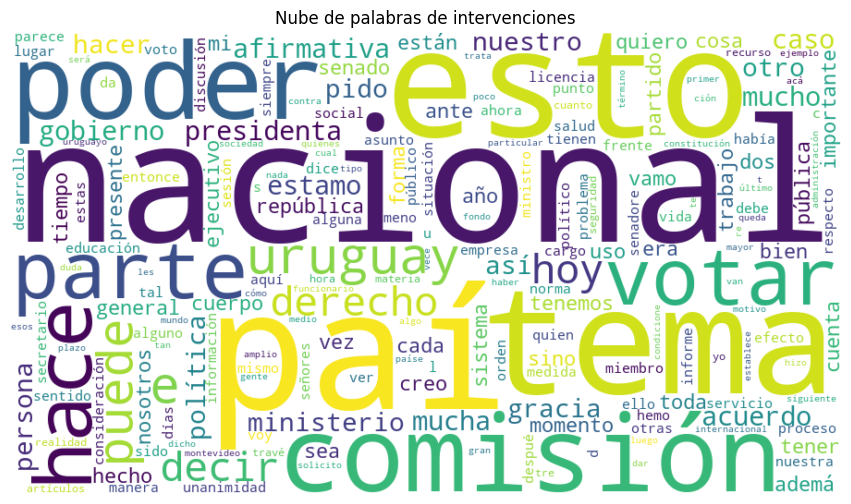

In [185]:
# ------------------------
# 8. Nube de palabras (quitando artículos, preps, etc.)
# ------------------------
stopwords = set([
    "de","la","que","el","en","y","a","los","del","se","las","por","un",
    "con","no","una","su","para","es","al","lo","como","más","pero","sus",
    "le","ya","o","fue","ha","si","sin","sobre","este","también","me","hasta",
    "hay","donde","han","ser","uno","entre","cuando","muy","años","desde",
    "porque","qué","solo","nos","durante","todo","esta","todos","sí","pues",
    "ni","misma","ese","otra","tanto","otros","ese","esa","ese","esas","estos","articulo","señor","señora",
    "palabra", "ley", "presidente", "día", "proyecto", "senador", "diputado", "senadora", "diputada",
    "va", "día", "n", "está", "artículo", "tiene","son", "eso", "estado"
,])

texto = " ".join(df["intervencion"].tolist())
texto = re.sub(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ ]", " ", texto)
texto = " ".join([t.lower() for t in texto.split() if t.lower() not in stopwords])

wc = WordCloud(width=900, height=500, background_color="white", collocations=False).generate(texto)
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de intervenciones")
plt.show()


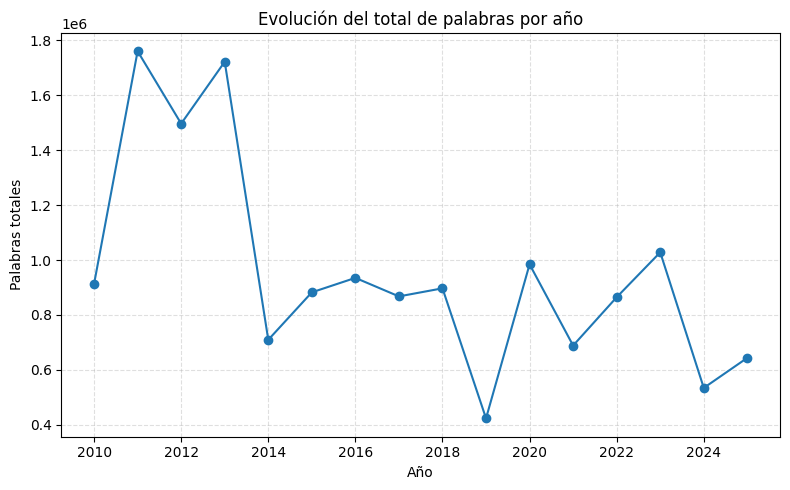

In [186]:
# ------------------------
# 10. Bonus: evolución temporal
# ------------------------
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["año"] = df["fecha"].dt.year
evol = df.groupby("año")["n_palabras"].sum().dropna()

plt.figure(figsize=(8,5))
evol.plot(marker="o")
plt.title("Evolución del total de palabras por año")
plt.xlabel("Año")
plt.ylabel("Palabras totales")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [187]:
# mujeres vs hombres

# Aseguramos que no haya NaN y pasamos a string
locs = df["locutor"].fillna("").astype(str)

# Filtramos fuera a Presidente/a
mask_presi = locs.str.contains(r'\bPRESIDENT(A|E)\b', case=False, regex=True)
locs_filtrados = locs[~mask_presi].str.strip()

# Clasificamos por género según el prefijo
def clasificar_genero(nombre):
    nombre_upper = nombre.upper()
    if nombre_upper.startswith("SEÑORA "):
        return "Mujer"
    elif nombre_upper.startswith("SEÑOR "):
        return "Hombre"
    else:
        return "No identificado"

df_genero = pd.DataFrame({
    "locutor": locs_filtrados,
    "genero": locs_filtrados.map(clasificar_genero)
})

# Contamos las intervenciones por género
conteo = df_genero["genero"].value_counts().reset_index()
conteo.columns = ["Género", "Intervenciones"]
conteo["Porcentaje"] = 100 * conteo["Intervenciones"] / conteo["Intervenciones"].sum()

from IPython.display import display
display(conteo.style.format({"Porcentaje": "{:.2f}%"}))

# Totales absolutos
total = conteo["Intervenciones"].sum()
print(f"Total de intervenciones (sin Presidencia): {total:,}")


C:\Users\flala\AppData\Local\Temp\ipykernel_9348\1586804477.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_presi = locs.str.contains(r'\bPRESIDENT(A|E)\b', case=False, regex=True)


,Género,Intervenciones,Porcentaje
0,Hombre,39580,80.92%
1,Mujer,9332,19.08%


Total de intervenciones (sin Presidencia): 48,912


In [188]:
# contar cuantos documentos tienen solo una intervención

# --- Parámetro ---
X = 2  # "menos de X": si querés "una sola intervención", poné X = 2

# --- Conteo de intervenciones por documento ---
# Asumimos que cada fila es una intervención y que 'file_name' identifica al documento/sesión.
doc_counts = (
    df.groupby("file_name")
      .size()
      .rename("intervenciones")
      .reset_index()
)

# Cámara por documento (tomamos la primera que aparezca)
doc_camara = (
    df.groupby("file_name")["cuerpo"]
      .first()
      .reset_index()
)

# Merge
docs = doc_counts.merge(doc_camara, on="file_name", how="left")
docs["cuerpo"] = docs["cuerpo"].fillna("DESCONOCIDO")

# --- Resultados globales ---
docs_con_una = (docs["intervenciones"] == 1).sum()
docs_menos_X = (docs["intervenciones"] < X).sum()
total_docs   = docs.shape[0]

print(f"Total de documentos: {total_docs:,}")
print(f"Documentos con UNA intervención: {docs_con_una:,}")
print(f"Documentos con < {X} intervenciones: {docs_menos_X:,}")

# --- Tabla por cámara: distribución (total vs. <X) ---
tabla_camara = (
    docs.assign(es_menor_X = docs["intervenciones"] < X)
        .groupby("cuerpo")
        .agg(
            docs_total = ("file_name", "nunique"),
            docs_ltX   = ("es_menor_X", "sum"),
        )
        .reset_index()
)

tabla_camara["%_ltX"] = 100 * tabla_camara["docs_ltX"] / tabla_camara["docs_total"]

from IPython.display import display
display(
    tabla_camara.sort_values("docs_total", ascending=False)
                .style.format({"docs_total": "{:,.0f}",
                               "docs_ltX": "{:,.0f}",
                               "%_ltX": "{:.2f}%"}))

# --- (Opcional) Si querés ver explícitamente los docs con una sola intervención:
docs_una = docs.loc[docs["intervenciones"] == 1, ["file_name", "cuerpo", "intervenciones"]]
# display(docs_una.head())


Total de documentos: 829
Documentos con UNA intervención: 5
Documentos con < 2 intervenciones: 5


,cuerpo,docs_total,docs_ltX,%_ltX
0,css,829,5,0.60%


In [189]:
# Filtrar los docs con una sola intervención
docs_una_interv_prueba = interv_x_doc[interv_x_doc == 1]

print(f"Documentos con una sola intervención: {len(docs_una_interv_prueba):,}")
docs_una_interv_prueba.head()


Documentos con una sola intervención: 5


file_name
48_2015-03-10_css.txt         1
48_2015-12-28_css_5554.txt    1
48_2019-11-04_css_6094.txt    1
49_2022-12-01_css.txt         1
50_2025-08-13_css.txt         1
dtype: int64

In [190]:
# Quitar los pedidos de palabra y concesión de palabra.

import pandas as pd

# Supongamos que tu DataFrame se llama df
# df = pd.read_csv("tu_archivo.csv", sep="\t")  # si viene de TSV

# --- 1. Filas originales ---
total_original = len(df)

# --- 2. Quitar intervenciones con "pido la palabra" o "tiene la palabra" ---
mask_palabra = df["intervencion"].str.contains(r"pido la palabra|tiene la palabra", case=False, na=False)
df_sin_palabra = df[~mask_palabra]
quitadas_palabra = mask_palabra.sum()

# --- 3. Quitar intervenciones con menos de 16 palabras ---
mask_cortas = df_sin_palabra["intervencion"].str.split().apply(len) < 16
df_limpio = df_sin_palabra[~mask_cortas]
quitadas_cortas = mask_cortas.sum()

# --- 4. Reporte ---
total_final = len(df_limpio)
total_quitadas = total_original - total_final

print("=== RESUMEN DE LIMPIEZA ===")
print(f"Total original: {total_original}")
print(f"Quitadas por 'pido/tiene la palabra': {quitadas_palabra}")
print(f"Quitadas por tener menos de 16 palabras: {quitadas_cortas}")
print(f"Total quitadas: {total_quitadas}")
print(f"Total final: {total_final}")

# Si querés guardar el resultado
# df_limpio.to_csv("data/df_limpio.csv", index=False)


=== RESUMEN DE LIMPIEZA ===
Total original: 99550
Quitadas por 'pido/tiene la palabra': 34857
Quitadas por tener menos de 16 palabras: 19506
Total quitadas: 54363
Total final: 45187


In [191]:
df_limpio.describe()

,n_legislatura,fecha,n_palabras,n_caracteres,año
count,45187.000000,45187,45187.000000,4.518700e+04,45187.000000
mean,48.099896,2017-11-15 02:54:03.640870144,297.671078,1.785137e+03,2017.284927
min,47.000000,2010-02-15 00:00:00,16.000000,5.900000e+01,2010.000000
25%,47.000000,2013-08-14 00:00:00,38.000000,2.210000e+02,2013.000000
50%,48.000000,2017-10-18 00:00:00,82.000000,4.850000e+02,2017.000000
75%,49.000000,2022-04-05 00:00:00,272.000000,1.612000e+03,2022.000000
max,50.000000,2025-10-27 00:00:00,176304.000000,1.087331e+06,2025.000000
std,0.928758,NaN,1321.990031,8.236298e+03,4.678327


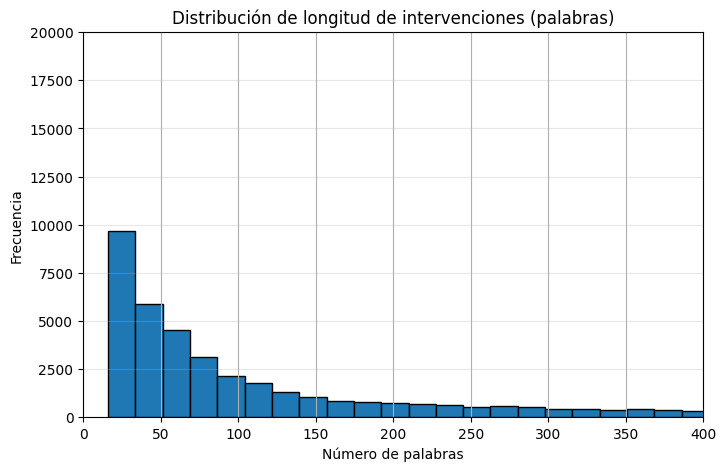

In [192]:
plt.figure(figsize=(8,5))
df_limpio["n_palabras"].hist(bins=10000, edgecolor="black")
plt.title("Distribución de longitud de intervenciones (palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)
plt.xlim(0, 400)  # eje X (fechas)
plt.ylim(0, 20000)                 # eje Y (montos)

plt.show()

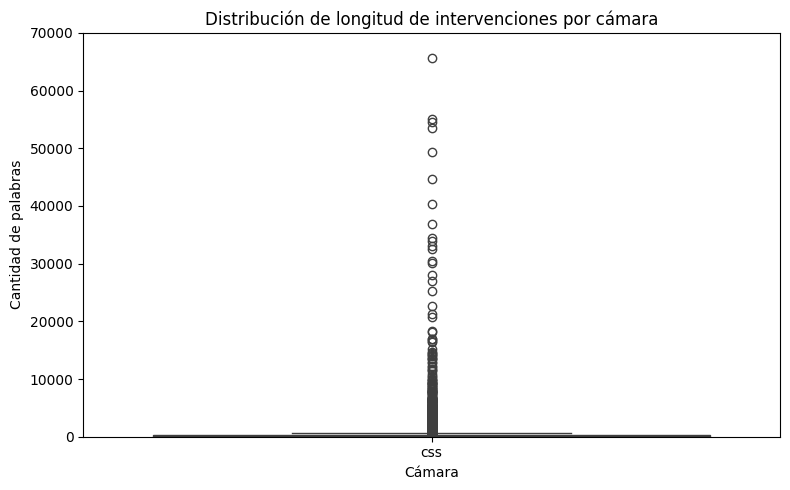

In [193]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cuerpo", y="n_palabras", data=df_limpio)
plt.title("Distribución de longitud de intervenciones por cámara")
plt.xlabel("Cámara")
plt.ylabel("Cantidad de palabras")
plt.ylim(0, 70000)
plt.tight_layout()
plt.show()

In [194]:
# Detección de outliers 

# --- Calcular cuartiles e IQR ---
q1 = df_limpio["n_palabras"].quantile(0.25)
q3 = df_limpio["n_palabras"].quantile(0.75)
iqr = q3 - q1

# --- Definir límites inferior y superior ---
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

# --- Detectar outliers ---
mask_outliers = (df_limpio["n_palabras"] < lim_inf) | (df_limpio["n_palabras"] > lim_sup)

# --- Contar ---
n_outliers = mask_outliers.sum()
total = len(df_limpio)
porcentaje = n_outliers / total * 100

print("=== DETECCIÓN DE ATÍPICOS (n_palabras) ===")
print(f"Total de filas: {total}")
print(f"Outliers detectados: {n_outliers} ({porcentaje:.2f}%)")
print(f"Límite inferior: {lim_inf:.1f}")
print(f"Límite superior: {lim_sup:.1f}")

=== DETECCIÓN DE ATÍPICOS (n_palabras) ===
Total de filas: 45187
Outliers detectados: 4969 (11.00%)
Límite inferior: -313.0
Límite superior: 623.0


In [195]:
q1 = df_limpio["n_palabras"].quantile(0.25)
q3 = df_limpio["n_palabras"].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

mask_outliers = (df_limpio["n_palabras"] < lim_inf) | (df_limpio["n_palabras"] > lim_sup)
df_outliers = df_limpio[mask_outliers]

# --- Resumen descriptivo ---
print("=== Estadísticas de los OUTLIERS ===")
print(df_outliers["n_palabras"].describe())

# --- Ver cuántos son 'bajos' y cuántos 'altos' ---
n_bajos = (df_outliers["n_palabras"] < lim_inf).sum()
n_altos = (df_outliers["n_palabras"] > lim_sup).sum()

print(f"\nOutliers por debajo del límite inferior: {n_bajos}")
print(f"Outliers por encima del límite superior: {n_altos}")
print(f"Proporción bajos/altos: {n_bajos}/{n_altos}")

=== Estadísticas de los OUTLIERS ===
count      4969.000000
mean       1645.252365
std        3700.371655
min         624.000000
25%         784.000000
50%        1073.000000
75%        1661.000000
max      176304.000000
Name: n_palabras, dtype: float64

Outliers por debajo del límite inferior: 0
Outliers por encima del límite superior: 4969
Proporción bajos/altos: 0/4969


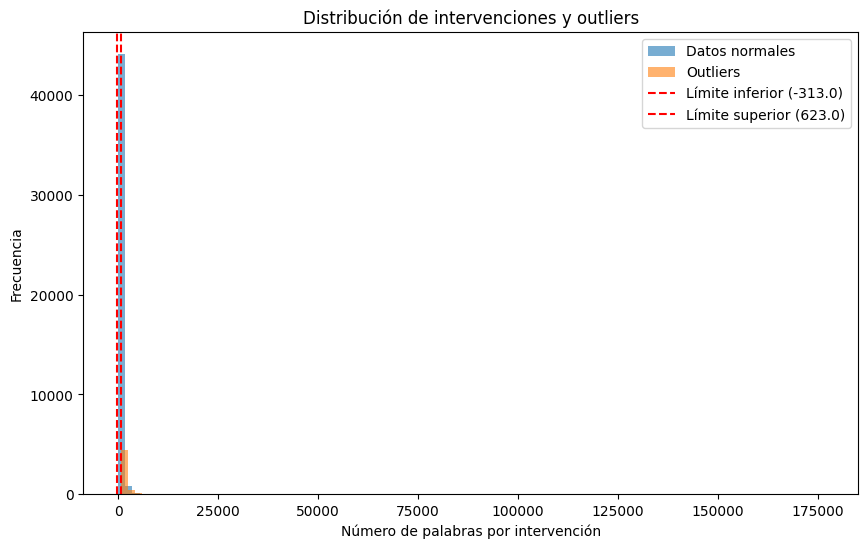

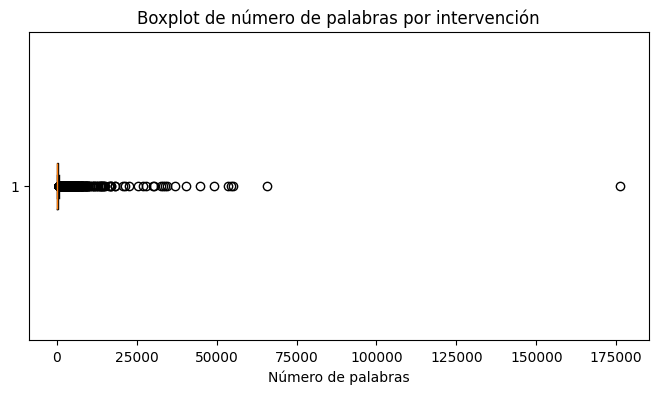

In [196]:


# --- Histograma general con outliers marcados ---
plt.figure(figsize=(10,6))
plt.hist(df_limpio["n_palabras"], bins=100, alpha=0.6, label="Datos normales")
plt.hist(df_outliers["n_palabras"], bins=100, alpha=0.6, label="Outliers")
plt.axvline(lim_inf, color='red', linestyle='--', label=f'Límite inferior ({lim_inf:.1f})')
plt.axvline(lim_sup, color='red', linestyle='--', label=f'Límite superior ({lim_sup:.1f})')
plt.xlabel("Número de palabras por intervención")
plt.ylabel("Frecuencia")
plt.title("Distribución de intervenciones y outliers")
plt.legend()
plt.show()

# --- Boxplot ---
plt.figure(figsize=(8,4))
plt.boxplot(df_limpio["n_palabras"], vert=False)
plt.title("Boxplot de número de palabras por intervención")
plt.xlabel("Número de palabras")
plt.show()


In [197]:
lim_sup = q3 + 1.5 * iqr

# Filtrar solo outliers altos
outliers_altos = df_limpio[df_limpio["n_palabras"] > lim_sup]

# Calcular percentiles dentro de los outliers altos
p75_out = outliers_altos["n_palabras"].quantile(0.75)

# Subconjunto con el último 25%
cola_superior = outliers_altos[outliers_altos["n_palabras"] > p75_out]

print("=== ANÁLISIS DE LA COLA SUPERIOR (último 25% de los outliers altos) ===")
print(f"Outliers altos totales: {len(outliers_altos)}")
print(f"Último 25% (cola superior): {len(cola_superior)} ({len(cola_superior)/len(outliers_altos)*100:.1f}%)")
print()
print(cola_superior["n_palabras"].describe())

=== ANÁLISIS DE LA COLA SUPERIOR (último 25% de los outliers altos) ===
Outliers altos totales: 4969
Último 25% (cola superior): 1238 (24.9%)

count      1238.000000
mean       3647.046850
std        7028.828467
min        1662.000000
25%        1917.250000
50%        2303.000000
75%        3075.000000
max      176304.000000
Name: n_palabras, dtype: float64


In [198]:
outliers_altos = df_limpio[df_limpio["n_palabras"] > lim_sup]

# --- 25% superior de los outliers altos ---
p75_out = outliers_altos["n_palabras"].quantile(0.75)
cola_superior = outliers_altos[outliers_altos["n_palabras"] > p75_out]

# --- 25% superior de esa cola (25% del 25%) ---
p75_cola = cola_superior["n_palabras"].quantile(0.75)
cola_mas_alta = cola_superior[cola_superior["n_palabras"] > p75_cola]

print("=== DISTRIBUCIÓN DEL 25% DEL 25% MÁS ALTO ===")
print(f"Total intervenciones en esta cola extrema: {len(cola_mas_alta)}")
print(cola_mas_alta["n_palabras"].describe())

=== DISTRIBUCIÓN DEL 25% DEL 25% MÁS ALTO ===
Total intervenciones en esta cola extrema: 309
count       309.000000
mean       8096.229773
std       13096.916318
min        3076.000000
25%        3483.000000
50%        4566.000000
75%        6787.000000
max      176304.000000
Name: n_palabras, dtype: float64


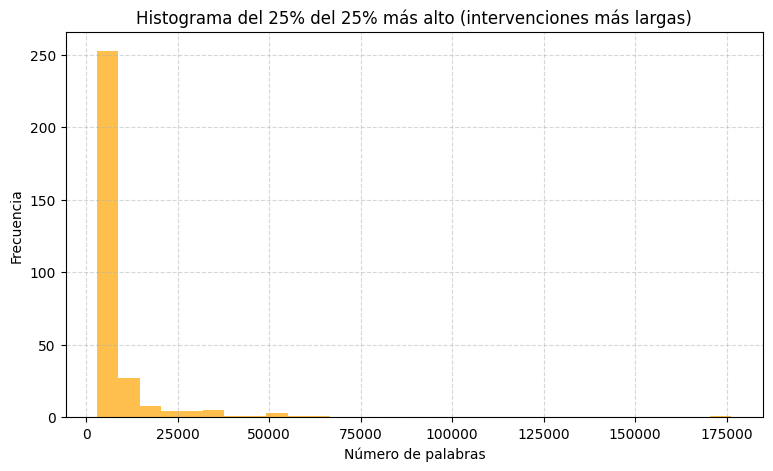

In [199]:
plt.figure(figsize=(9,5))
plt.hist(cola_mas_alta["n_palabras"], bins=30, color="orange", alpha=0.7)
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.title("Histograma del 25% del 25% más alto (intervenciones más largas)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [200]:
cola_mas_alta

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres,año
514,47_2010-03-17_css.txt,47,css,2010-03-17,SEÑOR PRESIDENTE,17) SOLICITUD DE VENIA DEL PODER EJECUTIVO PAR...,Se pasa a considerar el asunto que figura en s...,4724,28062,2010
732,47_2010-04-07_css.txt,47,css,2010-04-07,SEÑOR MINISTRO,6) CONVOCATORIA EN RÉGIMEN DE COMISIÓN GENERAL...,Señora Presidenta: es un gusto para nosotros h...,7690,47516,2010
1024,47_2010-04-28_css.txt,47,css,2010-04-28,SEÑOR PRESIDENTE,12) DESIGNACIÓN DEL INGENIERO JORGE CARLOS COL...,Se pasa a considerar el Mensaje relativo a OSE...,4330,28105,2010
2244,47_2010-07-07_css.txt,47,css,2010-07-07,SEÑOR ABREU,7) EXTENSIÓN DEL SEGURO POR DESEMPLEO DE LOS T...,"Señor Presidente: hemos votado esta prórroga, ...",6324,40214,2010
2553,47_2010-08-10_css.txt,47,css,2010-08-10,SEÑOR PRESIDENTE,17) ACUERDO MARCO ENTRE EL MERCOSUR Y EL GOBIE...,"Si no se hace uso de la palabra, se va a votar...",4671,30446,2010
...,...,...,...,...,...,...,...,...,...,...
95744,50_2025-04-09_css.txt,50,css,2025-04-09,SEÑOR CERVINI,16) HOMENAJE AL EXSENADOR ADRIÁN PEÑA,"Señora presidenta: antes que nada, quiero agra...",3304,18865,2025
97292,50_2025-07-16_css.txt,50,css,2025-07-16,SEÑOR SABINI,15) RENDICIÓN DE CUENTAS Y BALANCE DE EJECUCIÓ...,Señora presidenta: la Rendición de Cuentas y B...,4668,28124,2025
98048,50_2025-08-13_css_6917.txt,50,css,2025-08-13,SEÑOR ANDRADE,ORDEN DEL DÍA,Numa me recibió en la casa y él es uno de los ...,3570,20246,2025
98983,50_2025-10-10_css.txt,50,css,2025-10-10,SEÑOR SILVA,17) LEY INTEGRAL CONTRA EL LAVADO DE ACTIVOS. ...,"Señor presidente: sin duda, este es un tema mu...",3203,19062,2025


In [201]:
cola_mas_alta_sorted = cola_mas_alta.sort_values(by="n_palabras", ascending=False)

# Ver las primeras filas
cola_mas_alta_sorted.head(25)


,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres,año
8316,47_2011-04-12_css.txt,47,css,2011-04-12,SEÑOR PRESIDENTE,FUERZA AÉREA URUGUAYA:,"Si no se hace uso de la palabra, se va a votar...",176304,1087331,2011
21342,47_2013-03-05_css.txt,47,css,2013-03-05,SEÑOR PRESIDENTE,15) CÓDIGO GENERAL DEL PROCESO,El Senado pasa a considerar el asunto que figu...,65624,403206,2013
22643,47_2013-05-08_css.txt,47,css,2013-05-08,SEÑOR PRESIDENTE,13) IMPUESTO AL PATRIMONIO,Se pasa a considerar el asunto que figura en t...,55066,351715,2013
16344,47_2012-06-27_css.txt,47,css,2012-06-27,SEÑOR PRESIDENTE,7) PARTICIPACIONES PATRIMONIALES AL PORTADOR,"El Senado ingresa al Or den del Día, con la co...",54503,343130,2012
16228,47_2012-06-13_css.txt,47,css,2012-06-13,SEÑOR PRESIDENTE,16) 24º CONGRESO DE LA UNIÓN POSTAL UNIVERSAL ...,El Senado pasa a consi derar el asunto que fig...,53479,337688,2012
9764,47_2011-07-06_css.txt,47,css,2011-07-06,SEÑORA PRESIDENTA,12) ELECCIONES ESTATALES EN MÉXICO,Se va votar la moción formulada. -18 en 18. Af...,49334,322616,2011
22915,47_2013-05-15_css.txt,47,css,2013-05-15,SEÑOR PRESIDENTE,1) OJAODO SE TTATE <FE OEPÓSRTOS A PLAZO L-IJO...,En consideración. –26 en 26. Afirmativa. UNANI...,44693,281868,2013
24260,47_2013-08-06_css.txt,47,css,2013-08-06,SEÑOR GALLINAL,"14) HOMENAJE A LA EXFUNCIONARIA DEL SENADO, SE...",La Bancada del Partido Nacional solicita un cu...,40343,262863,2013
22904,47_2013-05-15_css.txt,47,css,2013-05-15,SEÑOR PRESIDENTE,13) ACTAS DEL CONGRESO XXI DE LA UNIÓN POSTAL ...,Se pasa a considerar el asunto que figura en p...,36881,235716,2013
11895,47_2011-10-05_css.txt,47,css,2011-10-05,SEÑOR PRESIDENTE,14) RENDICIÓN DE CUENTAS Y BALANCE DE EJECUCIÒ...,La Presidencia adhiere a los conceptos vertido...,34503,220977,2011


In [202]:
cola_mas_alta_sorted

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres,año
8316,47_2011-04-12_css.txt,47,css,2011-04-12,SEÑOR PRESIDENTE,FUERZA AÉREA URUGUAYA:,"Si no se hace uso de la palabra, se va a votar...",176304,1087331,2011
21342,47_2013-03-05_css.txt,47,css,2013-03-05,SEÑOR PRESIDENTE,15) CÓDIGO GENERAL DEL PROCESO,El Senado pasa a considerar el asunto que figu...,65624,403206,2013
22643,47_2013-05-08_css.txt,47,css,2013-05-08,SEÑOR PRESIDENTE,13) IMPUESTO AL PATRIMONIO,Se pasa a considerar el asunto que figura en t...,55066,351715,2013
16344,47_2012-06-27_css.txt,47,css,2012-06-27,SEÑOR PRESIDENTE,7) PARTICIPACIONES PATRIMONIALES AL PORTADOR,"El Senado ingresa al Or den del Día, con la co...",54503,343130,2012
16228,47_2012-06-13_css.txt,47,css,2012-06-13,SEÑOR PRESIDENTE,16) 24º CONGRESO DE LA UNIÓN POSTAL UNIVERSAL ...,El Senado pasa a consi derar el asunto que fig...,53479,337688,2012
...,...,...,...,...,...,...,...,...,...,...
16525,47_2012-06-27_css.txt,47,css,2012-06-27,SEÑOR PRESIDENTE,15) PARTICIPACIONES PATRIMONIALES AL PORTADOR,"Si se me permite una brevísima licencia, consi...",3096,19178,2012
81247,49_2023-04-11_css.txt,49,css,2023-04-11,SEÑOR CAGGIANI,20) REGISTRO DE PERSONERÍA JURÍDICA DE ORGANIZ...,Señora presidenta: como ban cada del Frente Am...,3092,18881,2023
76177,49_2022-08-02_css.txt,49,css,2022-08-02,SEÑORA LAZO,14) HOMENAJE A LA CANTANTE OLGA DELGROSSI,Señora presidenta: hoy este Senado en pleno se...,3086,18202,2022
65666,49_2020-09-01_css.txt,49,css,2020-09-01,SEÑOR ABREU,12) A DOSCIENTOS AÑOS DEL INGRESO DE NUESTRO H...,Señora presidenta: la dinámica po lítica nos d...,3078,18192,2020


Shape: (309, 10)

Columnas: ['file_name', 'n_legislatura', 'cuerpo', 'fecha', 'locutor', 'encabezado', 'intervencion', 'n_palabras', 'n_caracteres', 'año']


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
file_name,309,183,49_2020-09-30_css.txt,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_legislatura,309.0,NaN,NaN,NaN,47.566343,47.0,47.0,47.0,48.0,50.0,0.825506
cuerpo,309,1,css,309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha,309,NaN,NaN,NaN,2015-04-04 11:43:41.359223296,2010-03-17 00:00:00,2012-04-26 00:00:00,2013-07-30 00:00:00,2017-10-18 00:00:00,2025-10-10 00:00:00,NaN
locutor,309,85,SEÑOR PRESIDENTE,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
encabezado,309,235,ORDEN DEL DÍA,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
intervencion,309,309,En esto de hablar de la Rendición de Cuentas y...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_palabras,309.0,NaN,NaN,NaN,8096.229773,3076.0,3483.0,4566.0,6787.0,176304.0,13096.916318
n_caracteres,309.0,NaN,NaN,NaN,50574.229773,17874.0,21367.0,27920.0,41993.0,1087331.0,81923.558159
año,309.0,NaN,NaN,NaN,2014.634304,2010.0,2012.0,2013.0,2017.0,2025.0,4.007978


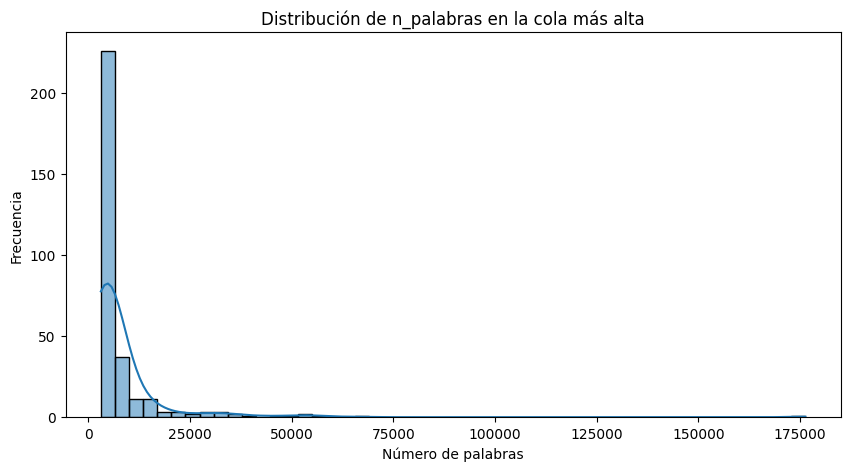

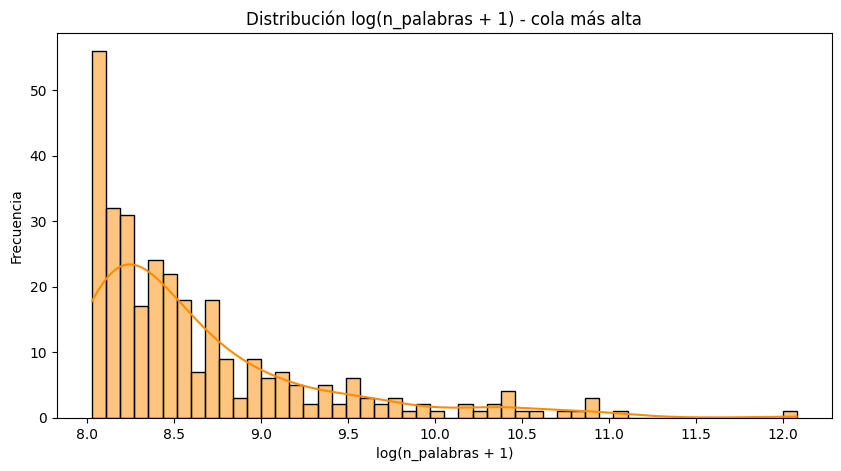

count       309.000000
mean       8096.229773
std       13096.916318
min        3076.000000
25%        3483.000000
50%        4566.000000
75%        6787.000000
90%       14207.400000
95%       27621.200000
99%       54421.080000
max      176304.000000
Name: n_palabras, dtype: float64


📜 Intervenciones más largas (top 5):


,file_name,locutor,n_palabras,intervencion
8316,47_2011-04-12_css.txt,SEÑOR PRESIDENTE,176304,"Si no se hace uso de la palabra, se va a votar..."
21342,47_2013-03-05_css.txt,SEÑOR PRESIDENTE,65624,El Senado pasa a considerar el asunto que figu...
22643,47_2013-05-08_css.txt,SEÑOR PRESIDENTE,55066,Se pasa a considerar el asunto que figura en t...
16344,47_2012-06-27_css.txt,SEÑOR PRESIDENTE,54503,"El Senado ingresa al Or den del Día, con la co..."
16228,47_2012-06-13_css.txt,SEÑOR PRESIDENTE,53479,El Senado pasa a consi derar el asunto que fig...



📜 Intervenciones menos largas dentro de la cola (bottom 5):


,file_name,locutor,n_palabras,intervencion
65135,49_2020-07-22_css.txt,SEÑORA KECHICHIAN,3076,En esto de hablar de la Rendición de Cuentas y...
65666,49_2020-09-01_css.txt,SEÑOR ABREU,3078,Señora presidenta: la dinámica po lítica nos d...
76177,49_2022-08-02_css.txt,SEÑORA LAZO,3086,Señora presidenta: hoy este Senado en pleno se...
81247,49_2023-04-11_css.txt,SEÑOR CAGGIANI,3092,Señora presidenta: como ban cada del Frente Am...
16525,47_2012-06-27_css.txt,SEÑOR PRESIDENTE,3096,"Si se me permite una brevísima licencia, consi..."


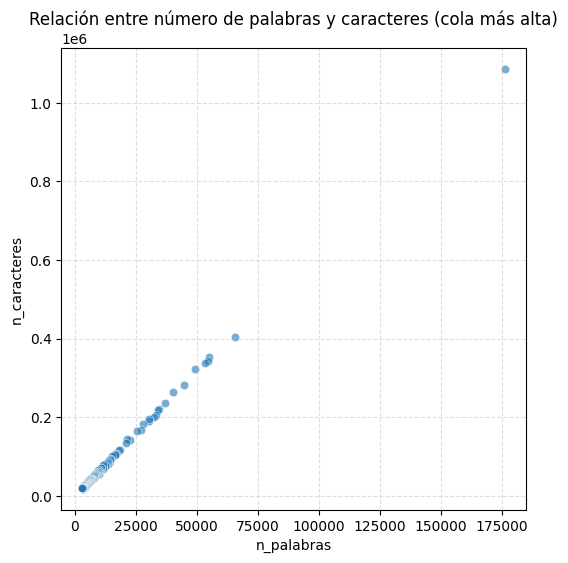

In [203]:
# ---------------------------------------------------------------------
# 1️⃣ Info general
# ---------------------------------------------------------------------
print("Shape:", cola_mas_alta_sorted.shape)
print("\nColumnas:", cola_mas_alta_sorted.columns.tolist())
display(cola_mas_alta_sorted.describe(include="all").T)

# ---------------------------------------------------------------------
# 2️⃣ Distribución de n_palabras
# ---------------------------------------------------------------------
plt.figure(figsize=(10,5))
sns.histplot(cola_mas_alta_sorted["n_palabras"], bins=50, kde=True)
plt.title("Distribución de n_palabras en la cola más alta")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

# ---------------------------------------------------------------------
# 3️⃣ Distribución logarítmica (para ver colas largas)
# ---------------------------------------------------------------------
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(cola_mas_alta_sorted["n_palabras"]), bins=50, kde=True, color="darkorange")
plt.title("Distribución log(n_palabras + 1) - cola más alta")
plt.xlabel("log(n_palabras + 1)")
plt.ylabel("Frecuencia")
plt.show()

# ---------------------------------------------------------------------
# 4️⃣ Estadísticas y percentiles
# ---------------------------------------------------------------------
desc = cola_mas_alta_sorted["n_palabras"].describe(percentiles=[.25,.5,.75,.9,.95,.99])
display(desc)

# ---------------------------------------------------------------------
# 5️⃣ Intervenciones extremas
# ---------------------------------------------------------------------
print("\n📜 Intervenciones más largas (top 5):")
display(cola_mas_alta_sorted.nlargest(5, "n_palabras")[["file_name", "locutor", "n_palabras", "intervencion"]])

print("\n📜 Intervenciones menos largas dentro de la cola (bottom 5):")
display(cola_mas_alta_sorted.nsmallest(5, "n_palabras")[["file_name", "locutor", "n_palabras", "intervencion"]])

# ---------------------------------------------------------------------
# 6️⃣ Relación entre n_palabras y n_caracteres
# ---------------------------------------------------------------------
plt.figure(figsize=(6,6))
sns.scatterplot(x="n_palabras", y="n_caracteres", data=cola_mas_alta_sorted, alpha=0.6)
plt.title("Relación entre número de palabras y caracteres (cola más alta)")
plt.xlabel("n_palabras")
plt.ylabel("n_caracteres")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# ---------------------------------------------------------------------
# 7️⃣ Si tenés columnas calculadas (ratio_noalf, car_por_pal, tiene_articulo_mal...)
# ---------------------------------------------------------------------
cols_existentes = [c for c in ["ratio_noalf", "car_por_pal", "tiene_articulo_mal", "tiene_ruido"] if c in cola_mas_alta_sorted.columns]

if cols_existentes:
    print("\n=== Variables de calidad detectadas:", cols_existentes, "===")
    
    # Boxplot de métricas numéricas de ruido
    num_cols = [c for c in cols_existentes if cola_mas_alta_sorted[c].dtype != bool]
    if num_cols:
        plt.figure(figsize=(8,4))
        sns.boxplot(data=cola_mas_alta_sorted[num_cols])
        plt.title("Distribución de métricas de calidad (cola más alta)")
        plt.show()
    
    # Conteo de banderas booleanas
    bool_cols = [c for c in cols_existentes if cola_mas_alta_sorted[c].dtype == bool]
    if bool_cols:
        print("\nConteo de banderas (True):")
        print(cola_mas_alta_sorted[bool_cols].sum())

In [204]:
# Cantidad de filas originales
original = len(df_limpio)

# Filtrar
df_limpio = df_limpio[df_limpio["n_palabras"] < 20000].copy()

# Cuántas se eliminaron
eliminadas = original - len(df_limpio)

print(f"Filas originales: {original}")
print(f"Eliminadas (>20.000 palabras): {eliminadas}")
print(f"Restantes: {len(df_limpio)}")


Filas originales: 45187
Eliminadas (>20.000 palabras): 21
Restantes: 45166


In [205]:
df_limpio

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres,año
5,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AMORÍN,DESCONOCIDO,"Sí, prometo. nor desempeñar debidamente el car...",20,119,2010
6,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡B...,37,229,2010
7,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡F...,34,222,2010
8,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡B...,37,230,2010
11,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡F...,34,225,2010
...,...,...,...,...,...,...,...,...,...,...
99548,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,9) RECTIFICACIÓN DE TRÁMITE,Queda usted investido del cargo de senador.\n–...,70,403,2025
99549,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,10) LUIS ALBERTO HEBER. SUBSIDIO,Léase la nota presentada por el exsenador Luis...,17,111,2025
99550,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,10) LUIS ALBERTO HEBER. SUBSIDIO,De conformidad con lo que establece el numeral...,58,322,2025
99551,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,11) SUSPENSIÓN DE LAS SESIONES ORDINARIAS,Léase una moción llegada a la mesa..\nSEÑOR SE...,41,245,2025


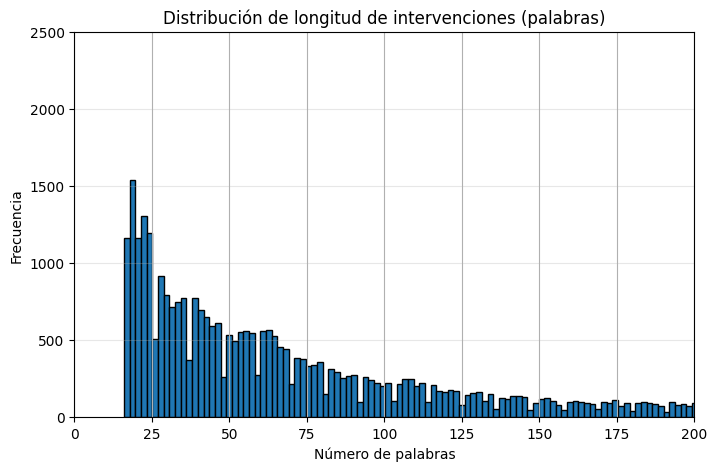

In [206]:
plt.figure(figsize=(8,5))
df_limpio["n_palabras"].hist(bins=10000, edgecolor="black")
plt.title("Distribución de longitud de intervenciones (palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)
plt.xlim(0, 200)  # eje X (fechas)
plt.ylim(0, 2500)                 # eje Y (montos)

plt.show()

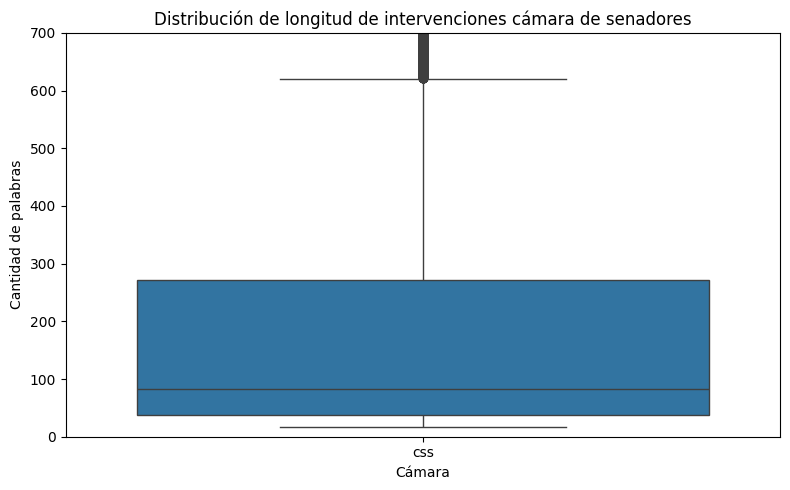

In [207]:
# ------------------------
# 6. Promedio de extensión (boxplot)
# ------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="cuerpo", y="n_palabras", data=df_limpio)
plt.title("Distribución de longitud de intervenciones cámara de senadores")
plt.xlabel("Cámara")
plt.ylabel("Cantidad de palabras")
plt.ylim(0, 700)
plt.tight_layout()
plt.show()

In [208]:
import pandas as pd
import numpy as np
from pathlib import Path

# === Parámetros ===
IN_PATH   = "../data/processed/df_final.jsonl"          # dataset limpio completo
OUT_JSONL = "../data/labeled/muestras_css_para_etiquetar.jsonl"
OUT_CSV   = "../data/labeled/muestras_css_para_etiquetar.csv"
N_TOTAL   = 1200                                    # total de muestras
N_BINS    = 6                                       # cantidad de estratos por largo
MIN_WORDS = 16                                      # excluir intervenciones muy cortas
RANDOM_STATE = 42

# === Cargar dataset final ===
df = pd.read_json(IN_PATH, lines=True)

# === Filtrar solo CSS (Senado) ===
df = df[df["cuerpo"].str.lower() == "css"].copy()

# === Largo de intervención ===
df["n_palabras_lbl"] = df["n_palabras"].fillna(0).astype(int)
df = df[df["n_palabras_lbl"] >= MIN_WORDS].copy()

# === Estratificación por largo (cuantiles) ===
quantiles = np.linspace(0, 1, N_BINS + 1)
cuts = df["n_palabras_lbl"].quantile(quantiles).round().astype(int).values
cuts = np.unique(cuts)
if len(cuts) <= 2:
    mi, ma = df["n_palabras_lbl"].min(), df["n_palabras_lbl"].max()
    cuts = np.linspace(mi, ma, N_BINS + 1)

df["estrato_len"] = pd.cut(
    df["n_palabras_lbl"],
    bins=cuts if isinstance(cuts, np.ndarray) else cuts,
    include_lowest=True,
    duplicates="drop"
)

# === Muestreo balanceado por estrato ===
estratos = sorted(df["estrato_len"].dropna().unique(), key=lambda x: (x.left, x.right))
n_por_bin = max(1, N_TOTAL // len(estratos))
rng = np.random.RandomState(RANDOM_STATE)

muestras = []
for e in estratos:
    sub = df[df["estrato_len"] == e]
    k = min(n_por_bin, len(sub))
    if k > 0:
        muestras.append(sub.sample(n=k, random_state=rng))

sample_bal = pd.concat(muestras, axis=0)

# Completar si faltan registros por bins pequeños
faltan = N_TOTAL - len(sample_bal)
if faltan > 0:
    restantes = df.drop(sample_bal.index)
    if not restantes.empty:
        extra = restantes.sample(n=min(faltan, len(restantes)), random_state=RANDOM_STATE)
        sample_bal = pd.concat([sample_bal, extra], axis=0)

# === Armar dataset para etiquetar ===
cols_out = [
    "file_name", "n_legislatura", "cuerpo", "fecha", "locutor",
    "encabezado", "intervencion", "n_palabras", "n_caracteres", "año"
]
out = sample_bal[cols_out].copy()
out["sentimiento"] = ""  # campo vacío para completar a mano

# === Guardar ===
Path(Path(OUT_JSONL).parent).mkdir(parents=True, exist_ok=True)
out.to_json(OUT_JSONL, orient="records", lines=True, force_ascii=False)
out.to_csv(OUT_CSV, index=False)

# === Reporte ===
resumen = (
    sample_bal
    .groupby("estrato_len")["n_palabras_lbl"]
    .agg(["count", "min", "median", "max"])
    .reset_index()
)
print("\nResumen por estrato (n_palabras):")
print(resumen.to_string(index=False))
print(f"\nGuardado:\n - {OUT_JSONL}\n - {OUT_CSV}\nTotal: {len(out)} intervenciones\n")



Resumen por estrato (n_palabras):
     estrato_len  count  min  median   max
  (15.999, 28.0]    200   16    22.0    28
    (28.0, 50.0]    200   29    38.0    50
    (50.0, 82.0]    200   51    65.0    82
   (82.0, 171.0]    200   83   115.5   171
  (171.0, 433.0]    200  172   270.0   430
(433.0, 18338.0]    200  436   737.0 14739

Guardado:
 - ../data/labeled/muestras_css_para_etiquetar.jsonl
 - ../data/labeled/muestras_css_para_etiquetar.csv
Total: 1200 intervenciones



C:\Users\flala\AppData\Local\Temp\ipykernel_9348\1990962507.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("estrato_len")["n_palabras_lbl"]


In [210]:
pwd

'c:\\Users\\flala\\OneDrive\\Desktop\\ORT\\Tesis\\Tesis-ORT-Benedetti-La-Laina\\src\\eda'

In [211]:
# Exportar JSON final
out_dir = Path("../data/processed"); out_dir.mkdir(parents=True, exist_ok=True)
df_limpio.to_csv(out_dir / "df_final.csv", index=False)


In [52]:
df_limpio

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres,año
5,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AMORÍN,DESCONOCIDO,"Sí, prometo. nor desempeñar debidamente el car...",20,119,2010
6,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡B...,37,229,2010
7,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡F...,34,222,2010
8,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡B...,37,230,2010
11,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡F...,34,225,2010
...,...,...,...,...,...,...,...,...,...,...
99548,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,9) RECTIFICACIÓN DE TRÁMITE,Queda usted investido del cargo de senador.\n–...,70,403,2025
99549,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,10) LUIS ALBERTO HEBER. SUBSIDIO,Léase la nota presentada por el exsenador Luis...,17,111,2025
99550,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,10) LUIS ALBERTO HEBER. SUBSIDIO,De conformidad con lo que establece el numeral...,58,322,2025
99551,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,11) SUSPENSIÓN DE LAS SESIONES ORDINARIAS,Léase una moción llegada a la mesa..\nSEÑOR SE...,41,245,2025


In [85]:
# contar locutores que tengan la palabra presid en el campo locutor
df_presid = df_limpio[df_limpio["locutor"].str.contains("president", case=False, na=False)]
df_presid

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres,año,apellido_locutor,apellido_locutor_norm,partido,sexo
6,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡B...,37,229,2010,PRESIDENTA,presidenta,None,None
7,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡F...,34,222,2010,PRESIDENTA,presidenta,None,None
8,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡B...,37,230,2010,PRESIDENTA,presidenta,None,None
11,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡F...,34,225,2010,PRESIDENTA,presidenta,None,None
14,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑORA PRESIDENTA,DESCONOCIDO,Queda usted investido del cargo de Senador. ¡F...,34,227,2010,PRESIDENTA,presidenta,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99548,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,9) RECTIFICACIÓN DE TRÁMITE,Queda usted investido del cargo de senador.\n–...,70,403,2025,PRESIDENTA,presidenta,None,None
99549,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,10) LUIS ALBERTO HEBER. SUBSIDIO,Léase la nota presentada por el exsenador Luis...,17,111,2025,PRESIDENTA,presidenta,None,None
99550,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,10) LUIS ALBERTO HEBER. SUBSIDIO,De conformidad con lo que establece el numeral...,58,322,2025,PRESIDENTA,presidenta,None,None
99551,50_2025-10-27_css.txt,50,css,2025-10-27,SEÑORA PRESIDENTA,11) SUSPENSIÓN DE LAS SESIONES ORDINARIAS,Léase una moción llegada a la mesa..\nSEÑOR SE...,41,245,2025,PRESIDENTA,presidenta,None,None


In [87]:
#Se quitan de df_limpio las filas donde el locutor contenga la palabra "president"
df_limpio = df_limpio[~df_limpio["locutor"].str.contains("president", case=False, na=False)]

In [111]:
df_parlamentarios = pd.read_csv("../data/raw/parlamentarios/ag_actuantes_legislaturas_sexo_imputado.csv")

In [112]:
# Se filtran los parlamentarios pertenecientes a la camara CSS
df_parlamentarios_css = df_parlamentarios[df_parlamentarios['camara'] == 'CSS']
df_parlamentarios_css

,fecha,camara,partido,apellido_norm,nombre_norm,sexo,sustituye_a
0,2010-02-15,CSS,FRENTE AMPLIO,topolansky,lucia,F,NaN
1,2010-02-15,CSS,NACIONAL,abreu,sergio,M,NaN
2,2010-02-15,CSS,FRENTE AMPLIO,agazzi,ernesto,M,NaN
3,2010-02-15,CSS,COLORADO,amorin,jose,M,NaN
4,2010-02-15,CSS,FRENTE AMPLIO,baraibar,carlos,M,NaN
...,...,...,...,...,...,...,...
710791,2025-11-22,CSS,COLORADO,zubia,gustavo,M,NaN
710800,2025-11-22,CSS,FRENTE AMPLIO,badin vidal,cecilia,F,NaN
710823,2025-11-22,CSS,FRENTE AMPLIO,garlo alonsoperez,joaquin,M,NaN
710829,2025-11-22,CSS,FRENTE AMPLIO,guerrero,gustavo,M,NaN


In [113]:
def extraer_sexo_apellido(locutor):
    if pd.isna(locutor):
        return pd.Series([None, None])

    loc = locutor.upper().strip()

    if loc.startswith("SEÑORA"):
        sexo = "F"
        apellido = re.sub(r"^SEÑORA\s+", "", loc)
    elif loc.startswith("SEÑOR"):
        sexo = "M"
        apellido = re.sub(r"^SEÑOR\s+", "", loc)
    else:
        sexo = None
        apellido = loc

    return pd.Series([sexo, apellido.strip()])


In [114]:
df_limpio[["sexo_locutor", "apellido_locutor"]] = (
    df_limpio["locutor"].apply(extraer_sexo_apellido)
)



C:\Users\flala\AppData\Local\Temp\ipykernel_9348\4098027657.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio[["sexo_locutor", "apellido_locutor"]] = (


In [115]:
def normalizar(texto):
    if pd.isna(texto):
        return None
    texto = texto.lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return texto

df_limpio["apellido_locutor_norm"] = df_limpio["apellido_locutor"].apply(normalizar)
df_parlamentarios_css["apellido_norm"] = df_parlamentarios_css["apellido_norm"].apply(normalizar)



C:\Users\flala\AppData\Local\Temp\ipykernel_9348\144359182.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio["apellido_locutor_norm"] = df_limpio["apellido_locutor"].apply(normalizar)
C:\Users\flala\AppData\Local\Temp\ipykernel_9348\144359182.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_parlamentarios_css["apellido_norm"] = df_parlamentarios_css["apellido_norm"].apply(normalizar)


In [116]:
df_limpio["fecha"] = pd.to_datetime(df_limpio["fecha"])
df_parlamentarios["fecha"] = pd.to_datetime(df_parlamentarios["fecha"])


C:\Users\flala\AppData\Local\Temp\ipykernel_9348\1462220757.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio["fecha"] = pd.to_datetime(df_limpio["fecha"])


In [117]:
from rapidfuzz import process, fuzz

def buscar_parlamentario(row, df_parl, score_min=85):

    if pd.isna(row["apellido_locutor_norm"]) or pd.isna(row["sexo_locutor"]):
        return pd.Series([None, None, None])

    candidatos = df_parl[
        (df_parl["fecha"] == row["fecha"]) &
        (df_parl["sexo"] == row["sexo_locutor"])
    ]

    if candidatos.empty:
        return pd.Series([None, None, None])

    match = process.extractOne(
        row["apellido_locutor_norm"],
        candidatos["apellido_norm"],
        scorer=fuzz.ratio
    )

    if match and match[1] >= score_min:
        fila = candidatos[candidatos["apellido_norm"] == match[0]].iloc[0]
        return pd.Series([
            fila["partido"],
            fila["sexo"],
            match[1]          # score para auditoría
        ])

    return pd.Series([None, None, None])



In [120]:
parl_dict = {
    (fecha, sexo): df
    for (fecha, sexo), df in
    df_parlamentarios.groupby(["fecha", "sexo"])
}


In [121]:
from rapidfuzz import process, fuzz

def buscar_parlamentario_fast(row, parl_dict, score_min=85):

    key = (row["fecha"], row["sexo_locutor"])

    if key not in parl_dict or pd.isna(row["apellido_locutor_norm"]):
        return pd.Series([None, None, None])

    candidatos = parl_dict[key]

    match = process.extractOne(
        row["apellido_locutor_norm"],
        candidatos["apellido_norm"],
        scorer=fuzz.ratio
    )

    if match and match[1] >= score_min:
        fila = candidatos[candidatos["apellido_norm"] == match[0]].iloc[0]
        return pd.Series([fila["partido"], fila["sexo"], match[1]])

    return pd.Series([None, None, None])


In [122]:
df_limpio[["partido", "sexo_imputado", "score_match"]] = df_limpio.apply(
    buscar_parlamentario_fast,
    axis=1,
    parl_dict=parl_dict
)


C:\Users\flala\AppData\Local\Temp\ipykernel_9348\2220867815.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio[["partido", "sexo_imputado", "score_match"]] = df_limpio.apply(
C:\Users\flala\AppData\Local\Temp\ipykernel_9348\2220867815.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio[["partido", "sexo_imputado", "score_match"]] = df_limpio.apply(
C:\Users\flala\AppData\Local\Temp\ipykernel_9348\2220867815.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [123]:
df_limpio



,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres,año,apellido_locutor,apellido_locutor_norm,partido,sexo,sexo_locutor,sexo_imputado,score_match
5,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AMORÍN,DESCONOCIDO,"Sí, prometo. nor desempeñar debidamente el car...",20,119,2010,AMORÍN,amorin,COLORADO,M,M,M,100.0
100,47_2010-02-18_css.txt,47,css,2010-02-18,SEÑOR SANABRIA,ORDEN DEL DÍA,"Sí, prometo. –Léase.\nDe mi mayor consideració...",23,123,2010,SANABRIA,sanabria,None,None,M,None,NaN
108,47_2010-02-18_css.txt,47,css,2010-02-18,SEÑOR LORIER,ORDEN DEL DÍA,Señora Presidenta: solicito una rectificación ...,90,536,2010,LORIER,lorier,FRENTE AMPLIO,M,M,M,100.0
115,47_2010-03-03_css.txt,47,css,2010-03-03,SEÑOR LACALLE HERRERA,ORDEN DEL DÍA,Señor Presidente: me pareció entender que la a...,58,344,2010,LACALLE HERRERA,lacalle herrera,NACIONAL,M,M,M,100.0
120,47_2010-03-03_css.txt,47,css,2010-03-03,SEÑOR LACALLE HERRERA,5) INASISTENCIAS ANTERIORES (SE DA DE LAS SIGU...,"O, por lo menos, entre quienes así lo solicite...",44,275,2010,LACALLE HERRERA,lacalle herrera,NACIONAL,M,M,M,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99519,50_2025-10-14_css.txt,50,css,2025-10-14,SEÑOR OJEDA,28) SUSPENSIÓN DE LA SESIÓN ORDINARIA,Se votó un cuarto intermedio. Lo único que se ...,48,274,2025,OJEDA,ojeda,COLORADO,M,M,M,100.0
99536,50_2025-10-15_css.txt,50,css,2025-10-15,SEÑOR SILVA,"7) INASISTENCIAS ANTERIORES DE SENADORES, DESE...",Señora presidenta: retomando la discusión del ...,711,4174,2025,SILVA,silva,COLORADO,M,M,M,100.0
99539,50_2025-10-15_css.txt,50,css,2025-10-15,SEÑORA BIANCHI,"7) INASISTENCIAS ANTERIORES DE SENADORES, DESE...","Buenos días a todos.\nComo decía, me llama la ...",709,4063,2025,BIANCHI,bianchi,NACIONAL,F,F,F,100.0
99541,50_2025-10-15_css.txt,50,css,2025-10-15,SEÑOR GLOODTDOFSKY,"7) INASISTENCIAS ANTERIORES DE SENADORES, DESE...","Señor presidente: heme aquí, después de una la...",621,4058,2025,GLOODTDOFSKY,gloodtdofsky,FRENTE AMPLIO,M,M,M,100.0


In [125]:
#se listan de df_limpio los locutores que no se pudieron asociar a un partido o sexo
df_no_asociados = df_limpio[df_limpio["partido"].isna() | df_limpio["sexo_locutor"].isna()]
df_no_asociados

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres,año,apellido_locutor,apellido_locutor_norm,partido,sexo,sexo_locutor,sexo_imputado,score_match
100,47_2010-02-18_css.txt,47,css,2010-02-18,SEÑOR SANABRIA,ORDEN DEL DÍA,"Sí, prometo. –Léase.\nDe mi mayor consideració...",23,123,2010,SANABRIA,sanabria,None,None,M,None,NaN
153,47_2010-03-03_css.txt,47,css,2010-03-03,SEÑOR PASQUET,10) DETERMINACIÓN DEL RÉGIMEN DE TRABAJO DEL S...,Oportunamente recibimos la comunicación de los...,27,196,2010,PASQUET,pasquet,None,None,M,None,NaN
270,47_2010-03-03_css.txt,47,css,2010-03-03,SEÑOR PASQUET,14) DECLARACIÓN DE APOYO AL GOBIERNO CHILENO,"En nombre de la Bancada del Partido Colorado, ...",142,857,2010,PASQUET,pasquet,None,None,M,None,NaN
275,47_2010-03-03_css.txt,47,css,2010-03-03,SEÑOR PASQUET,15) FALLECIMIENTO DEL CIUDADANO CUBANO ORLANDO...,Señor Presidente: voy a fundar brevemente esta...,663,4010,2010,PASQUET,pasquet,None,None,M,None,NaN
321,47_2010-03-03_css.txt,47,css,2010-03-03,SEÑOR BORDABERRY,15) FALLECIMIENTO DEL CIUDADANO CUBANO ORLANDO...,Señor Presidente: voy a hacer una breve alusió...,105,582,2010,BORDABERRY,bordaberry,None,None,M,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99458,50_2025-10-14_css.txt,50,css,2025-10-14,SEÑOR GLOODTDOFSKY,DESIGNACIÓN COMO EMBAJADORA,Señor presidente: no sé si volveré a tener opo...,261,1476,2025,GLOODTDOFSKY,gloodtdofsky,None,None,M,None,NaN
99469,50_2025-10-14_css.txt,50,css,2025-10-14,SEÑOR BORDABERRY,DESIGNACIÓN COMO EMBAJADORA,Señor presidente: me une a Carolina Ache y a s...,629,3533,2025,BORDABERRY,bordaberry,None,None,M,None,NaN
99475,50_2025-10-14_css.txt,50,css,2025-10-14,SEÑOR BRENTA,DESIGNACIÓN COMO EMBAJADORA,"Gracias, señor presidente.\nPodía haber pedido...",205,1223,2025,BRENTA,brenta,None,None,M,None,NaN
99477,50_2025-10-14_css.txt,50,css,2025-10-14,SEÑOR BRENTA,DESIGNACIÓN COMO EMBAJADORA,…quiero trasmitir a los seño res senadores Bot...,385,2275,2025,BRENTA,brenta,None,None,M,None,NaN


In [128]:
df_no_match = df_limpio[df_limpio["partido"].isna()].copy()


In [129]:
tabla_estable = (
    df_parlamentarios
    .groupby(["apellido_norm", "sexo"])["partido"]
    .nunique()
    .reset_index(name="n_partidos")
)


In [130]:
tabla_estable = tabla_estable[tabla_estable["n_partidos"] == 1]

In [131]:
tabla_estable = (
    tabla_estable
    .merge(
        df_parlamentarios[["apellido_norm", "sexo", "partido"]],
        on=["apellido_norm", "sexo"],
        how="left"
    )
    .drop_duplicates(subset=["apellido_norm", "sexo"])
)


In [132]:
df_no_match = df_no_match.merge(
    tabla_estable,
    left_on=["apellido_locutor_norm", "sexo_locutor"],
    right_on=["apellido_norm", "sexo"],
    how="left"
)


In [138]:
for col in ["partido", "sexo_imputado", "score_match", "metodo_imputacion"]:
    if col not in df_limpio.columns:
        df_limpio[col] = pd.NA



C:\Users\flala\AppData\Local\Temp\ipykernel_9348\3275226913.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio[col] = pd.NA


In [141]:
df_no_match = df_limpio[df_limpio["partido"].isna()].copy()
df_no_match["idx_limpio"] = df_no_match.index


In [142]:
df_no_match = df_no_match.merge(
    tabla_estable,
    left_on=["apellido_locutor_norm", "sexo_locutor"],
    right_on=["apellido_norm", "sexo"],
    how="left",
    suffixes=("", "_imp")
)


In [143]:
idx = df_no_match.loc[df_no_match["partido_imp"].notna(), "idx_limpio"]

df_limpio.loc[idx, "partido"] = (
    df_no_match.set_index("idx_limpio")
    .loc[idx, "partido_imp"]
)

df_limpio.loc[idx, "sexo_imputado"] = (
    df_no_match.set_index("idx_limpio")
    .loc[idx, "sexo"]
)

df_limpio.loc[idx, "score_match"] = 100
df_limpio.loc[idx, "metodo_imputacion"] = "apellido+sexo_sin_fecha"


In [144]:
df_limpio

,file_name,n_legislatura,cuerpo,fecha,locutor,encabezado,intervencion,n_palabras,n_caracteres,año,apellido_locutor,apellido_locutor_norm,partido,sexo,sexo_locutor,sexo_imputado,score_match,metodo_imputacion
5,47_2010-02-15_css.txt,47,css,2010-02-15,SEÑOR AMORÍN,DESCONOCIDO,"Sí, prometo. nor desempeñar debidamente el car...",20,119,2010,AMORÍN,amorin,COLORADO,M,M,M,100.0,<NA>
100,47_2010-02-18_css.txt,47,css,2010-02-18,SEÑOR SANABRIA,ORDEN DEL DÍA,"Sí, prometo. –Léase.\nDe mi mayor consideració...",23,123,2010,SANABRIA,sanabria,COLORADO,None,M,None,100.0,apellido+sexo_sin_fecha
108,47_2010-02-18_css.txt,47,css,2010-02-18,SEÑOR LORIER,ORDEN DEL DÍA,Señora Presidenta: solicito una rectificación ...,90,536,2010,LORIER,lorier,FRENTE AMPLIO,M,M,M,100.0,<NA>
115,47_2010-03-03_css.txt,47,css,2010-03-03,SEÑOR LACALLE HERRERA,ORDEN DEL DÍA,Señor Presidente: me pareció entender que la a...,58,344,2010,LACALLE HERRERA,lacalle herrera,NACIONAL,M,M,M,100.0,<NA>
120,47_2010-03-03_css.txt,47,css,2010-03-03,SEÑOR LACALLE HERRERA,5) INASISTENCIAS ANTERIORES (SE DA DE LAS SIGU...,"O, por lo menos, entre quienes así lo solicite...",44,275,2010,LACALLE HERRERA,lacalle herrera,NACIONAL,M,M,M,100.0,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99519,50_2025-10-14_css.txt,50,css,2025-10-14,SEÑOR OJEDA,28) SUSPENSIÓN DE LA SESIÓN ORDINARIA,Se votó un cuarto intermedio. Lo único que se ...,48,274,2025,OJEDA,ojeda,COLORADO,M,M,M,100.0,<NA>
99536,50_2025-10-15_css.txt,50,css,2025-10-15,SEÑOR SILVA,"7) INASISTENCIAS ANTERIORES DE SENADORES, DESE...",Señora presidenta: retomando la discusión del ...,711,4174,2025,SILVA,silva,COLORADO,M,M,M,100.0,<NA>
99539,50_2025-10-15_css.txt,50,css,2025-10-15,SEÑORA BIANCHI,"7) INASISTENCIAS ANTERIORES DE SENADORES, DESE...","Buenos días a todos.\nComo decía, me llama la ...",709,4063,2025,BIANCHI,bianchi,NACIONAL,F,F,F,100.0,<NA>
99541,50_2025-10-15_css.txt,50,css,2025-10-15,SEÑOR GLOODTDOFSKY,"7) INASISTENCIAS ANTERIORES DE SENADORES, DESE...","Señor presidente: heme aquí, después de una la...",621,4058,2025,GLOODTDOFSKY,gloodtdofsky,FRENTE AMPLIO,M,M,M,100.0,<NA>


In [ ]:
ambiguedad = (
    df_parlamentarios_css
    .groupby("apellido_norm")
    .agg(
        n_partidos=("partido", "nunique"),
        n_sexos=("sexo", "nunique")
    )
    .reset_index()
)

apellidos_conflictivos = ambiguedad[
    (ambiguedad["n_partidos"] > 1) |
    (ambiguedad["n_sexos"] > 1)
]["apellido_norm"]


In [ ]:
df_homonimos = df_parlamentarios_css[
    df_parlamentarios_css["apellido_norm"].isin(apellidos_conflictivos)
].sort_values(["apellido_norm", "fecha"])


df_homonimos_unicos = (
    df_homonimos
    .drop_duplicates(
        subset=["partido", "apellido_norm", "nombre_norm", "sexo"]
    )
    .sort_values(["apellido_norm", "nombre_norm"])
)


In [166]:
df_homonimos_unicos

,fecha,camara,partido,apellido_norm,nombre_norm,sexo,sustituye_a
321854,2017-08-16,CSS,NACIONAL,alonso,jorge,M,NaN
21785,2010-08-03,CSS,NACIONAL,alonso,veronica,F,NaN
377674,2018-10-23,CSS,NACIONAL,alvarez lopez,maria,F,"la Senadora Alonso, Verónica durante la licenc..."
2878,2010-03-10,CSS,FRENTE AMPLIO,alvarez lopez,pablo,M,NaN
211744,2015-04-15,CSS,COLORADO,bianchi,daniel,M,"la Senadora Montaner, Martha durante la licenc..."
6361,2010-04-06,CSS,FRENTE AMPLIO,bianchi,eleonora,F,NaN
439645,2020-02-15,CSS,NACIONAL,bianchi,graciela,F,NaN
10894,2010-05-11,CSS,COLORADO,cardoso,german,M,NaN
66349,2011-07-13,CSS,NACIONAL,cardoso,jose,M,NaN
635525,2024-04-17,CSS,NACIONAL,correa,julio,M,NaN
